# CCO13: Jie

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import seaborn as sns

import sys
sys.path.insert(0, "/home/herbert/work/cocultured_organ/src")
import DEG

In [2]:
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO13"
DATA_DIR = "/home/herbert/PyProjects/cocultured_organ/data/260402"

In [3]:
os.system(f"mkdir -p {WORK_DIR}")

0

# 0. Data

In [29]:
os.system(f"mkdir -p {WORK_DIR}/adata/raw")

0

In [120]:
os.system(f"ls -l {DATA_DIR}/*.h5")

-rw-r--r-- 1 herbert yachilab 21022207 Jul 28 09:34 /home/herbert/PyProjects/cocultured_organ/data/260402/OCM2-AFENC8-JJ-022626-R.h5
-rw-r--r-- 1 herbert yachilab  3825822 Jul 28 09:46 /home/herbert/PyProjects/cocultured_organ/data/260402/OCM2-AFEWTC-JJ-022626-B.h5
-rw-r--r-- 1 herbert yachilab  6943525 Jul 28 09:46 /home/herbert/PyProjects/cocultured_organ/data/260402/OCM2-IPSNC8-JJ-022626-G.h5
-rw-r--r-- 1 herbert yachilab  2735413 Jul 28 09:47 /home/herbert/PyProjects/cocultured_organ/data/260402/OCM2-IPSWTC-JJ-022626-Y.h5


0

In [131]:
adata_all = None

for f in glob.glob(f"{DATA_DIR}/*.h5"):
    batch = f.split("/")[-1].split("-")[0]
    cell_line = f.split("/")[-1].split("-")[1]

    adata = sc.read_10x_h5(f)
    adata.var_names_make_unique()
    adata.obs["batch"] = batch
    adata.obs["cell_line"] = cell_line
    
    if adata_all is None:
        adata_all = adata
    else:
        adata_all = ad.concat([adata_all, adata])

adata_all.write(f"{WORK_DIR}/adata/raw/ALL.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarn

# 1. preprocessing

In [17]:
PCT_MT_CUTOFF = 5

## 1.1

In [4]:
os.system(f"mkdir -p {WORK_DIR}/adata/processed")

0

In [13]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/raw/ALL.h5ad")

In [14]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True)

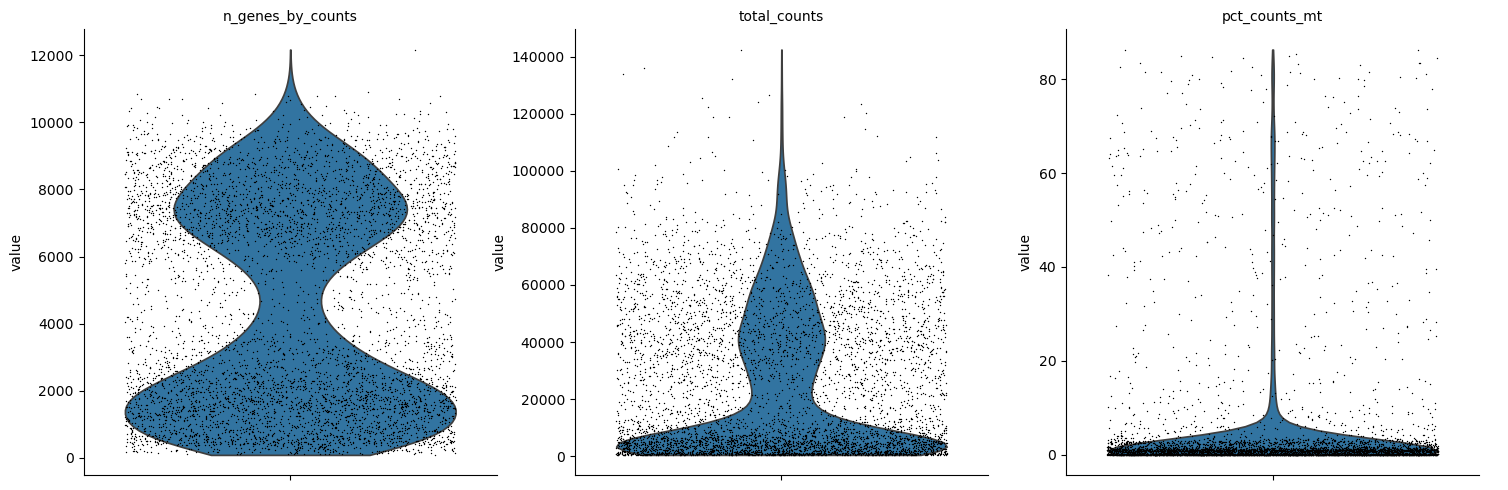

In [15]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

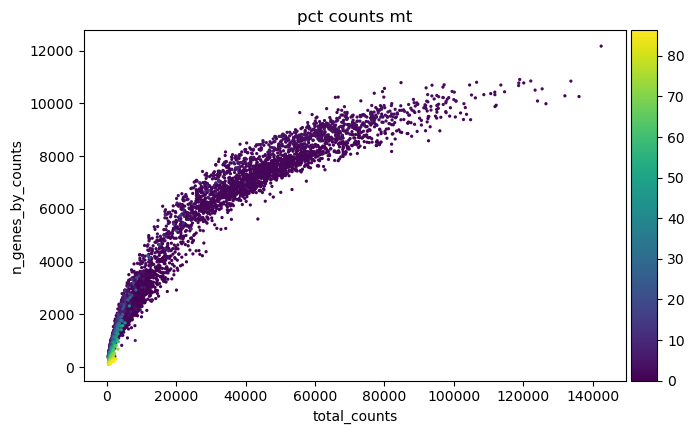

In [16]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

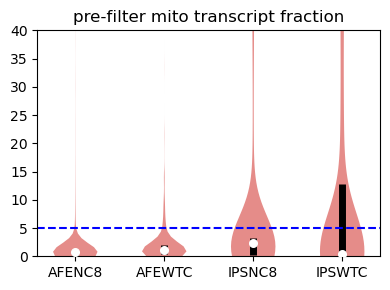

In [17]:
cls = list(adata.obs["cell_line"].unique().sort_values())
dt = []

fig, ax = plt.subplots(1, 1, figsize=(4, 3))

for i, cl in enumerate(cls):
    adata_sub = adata[adata.obs["cell_line"] == cl]
    d = adata_sub.obs["pct_counts_mt"].to_list()
    dt.append(d)
    quartile1, medians, quartile3 = np.percentile(d, [25, 50, 75])
    ax.vlines(i+1, quartile1, quartile3, color='k', linestyle='-', lw=5)
    ax.scatter(i+1, medians, marker='o', color='white', s=30, zorder=3)

violin_parts = ax.violinplot(dt, showmeans=False, showmedians=False, showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor("#D43F3A")
    pc.set_alpha(0.6)

ax.set_ylim(0, 40)
ax.set_xticks(np.arange(1, len(cls)+1), cls)
ax.set_title("pre-filter mito transcript fraction")
ax.axhline(PCT_MT_CUTOFF, linestyle="--", color="blue")

plt.tight_layout()
plt.show()

In [18]:
n_old = adata.n_obs

adata = adata[adata.obs["pct_counts_mt"] < PCT_MT_CUTOFF]
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

print(f"removed due to mito percent or count: {n_old - adata.n_obs}")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


removed due to mito percent or count: 595


In [46]:
n_old = adata.n_obs

sc.external.pp.scrublet(adata, batch_key="batch", random_state=42)
adata = adata[np.logical_not(adata.obs["predicted_doublet"])]

print(f"removed due to doublet: {n_old - adata.n_obs}")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:250: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['n_cells'] = number
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Automatically set threshold at doublet score = 0.44
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 11.8%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
removed due to doublet: 0


In [47]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [48]:
sc.tl.pca(adata, n_comps=100, random_state=42, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=1000, n_pcs=100, random_state=42)
sc.tl.leiden(adata, resolution=0.5, random_state=42)
sc.tl.umap(adata, random_state=42)

In [49]:
adata.obs = adata.obs[["pct_counts_mt", "batch", "cell_line", "leiden"]]

In [50]:
adata.write(f"{WORK_DIR}/adata/processed/ALL.h5ad")

## 1.2 visualization

In [4]:
os.system(f"mkdir -p {WORK_DIR}/visual")

0

In [5]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/processed/ALL.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


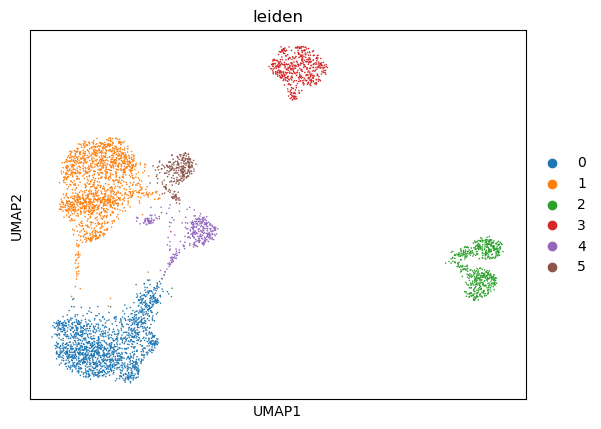

In [6]:
sc.pl.umap(adata, color="leiden", s=5, show=False)
plt.savefig(f"{WORK_DIR}/visual/UMAP.leiden.png", bbox_inches="tight")
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


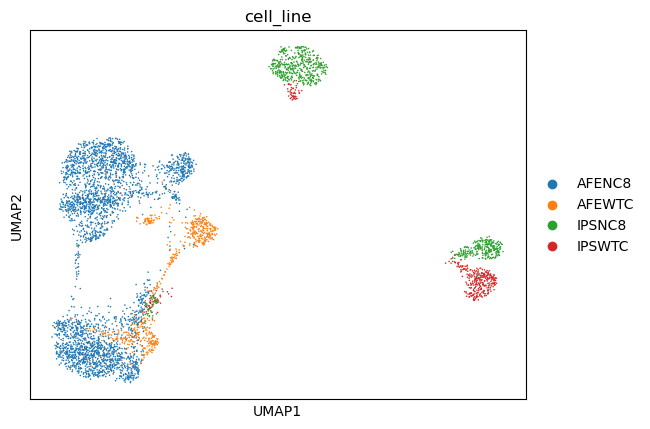

In [7]:
sc.pl.umap(adata, color="cell_line", s=5, show=False)
plt.savefig(f"{WORK_DIR}/visual/UMAP.cell_line.png", bbox_inches="tight")
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


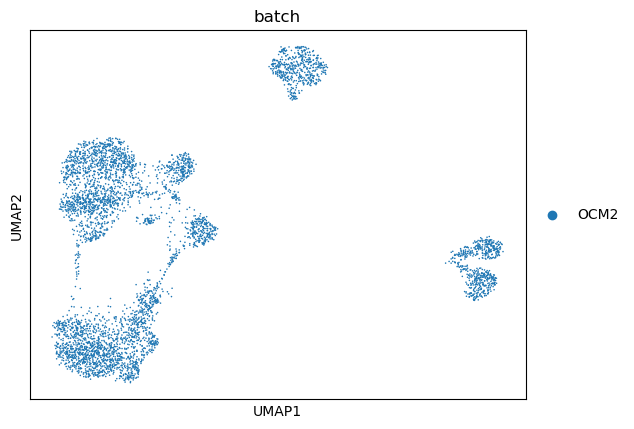

In [8]:
sc.pl.umap(adata, color="batch", s=5)

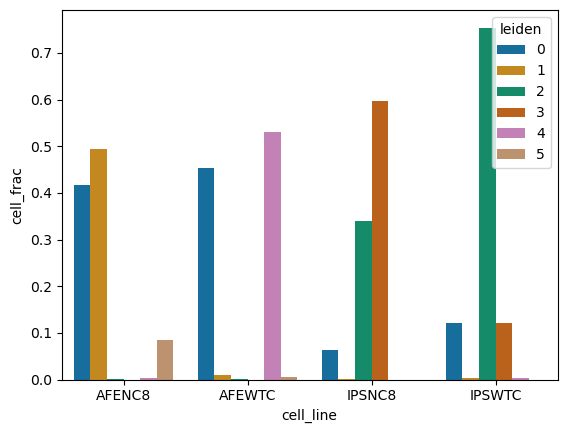

In [13]:
df = adata.obs[["leiden", "cell_line"]].copy()
df["leiden"] = df["leiden"].astype(int)
df["cell_line"] = df["cell_line"].astype(str)

df_plt = {"cell_line": [], "leiden": [], "cell_count": []}

for cl in ("AFENC8", "AFEWTC", "IPSNC8", "IPSWTC"):
    df_sub = df[df["cell_line"] == cl]
    for l in range(0, 6):
        try:
            n = df_sub.leiden.value_counts()[l]
        except:
            n = 0
        df_plt["cell_line"].append(cl)
        df_plt["leiden"].append(l)
        df_plt["cell_count"].append(n)

df_plt = pd.DataFrame(df_plt)
df_plt["cell_frac"] = 0
for i in range(0, df_plt.shape[0]):
    df_plt.iloc[i, 3] = df_plt.iloc[i, 2] / df_plt[df_plt["cell_line"] == df_plt.iloc[i,0]]["cell_count"].sum()
sns.barplot(df_plt, y="cell_frac", x="cell_line", hue="leiden", palette="colorblind")

plt.savefig(f"{WORK_DIR}/visual/cell_fraction.cell_line.png", bbox_inches="tight")
plt.show()

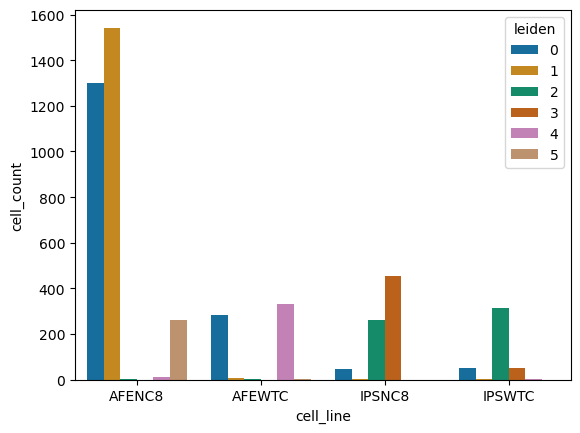

In [14]:
sns.barplot(df_plt, y="cell_count", x="cell_line", hue="leiden", palette="colorblind")
plt.savefig(f"{WORK_DIR}/visual/cell_count.cell_line.png", bbox_inches="tight")
plt.show()

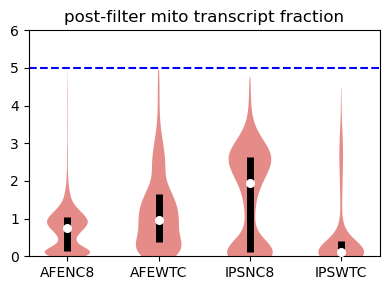

In [18]:
cls = list(adata.obs["cell_line"].unique().sort_values())
dt = []

fig, ax = plt.subplots(1, 1, figsize=(4, 3))

for i, cl in enumerate(cls):
    adata_sub = adata[adata.obs["cell_line"] == cl]
    d = adata_sub.obs["pct_counts_mt"].to_list()
    dt.append(d)
    quartile1, medians, quartile3 = np.percentile(d, [25, 50, 75])
    ax.vlines(i+1, quartile1, quartile3, color='k', linestyle='-', lw=5)
    ax.scatter(i+1, medians, marker='o', color='white', s=30, zorder=3)

violin_parts = ax.violinplot(dt, showmeans=False, showmedians=False, showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor("#D43F3A")
    pc.set_alpha(0.6)

ax.set_ylim(0, 6)
ax.set_xticks(np.arange(1, len(cls)+1), cls)
ax.set_title("post-filter mito transcript fraction")
ax.axhline(PCT_MT_CUTOFF, linestyle="--", color="blue")

plt.tight_layout()
plt.show()

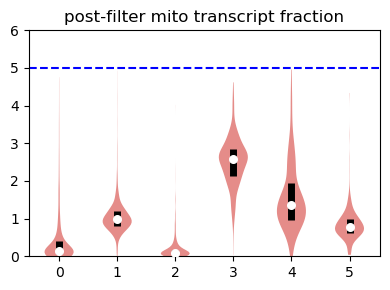

In [20]:
cls = list(adata.obs["leiden"].unique().sort_values())
dt = []

fig, ax = plt.subplots(1, 1, figsize=(4, 3))

for i, cl in enumerate(cls):
    adata_sub = adata[adata.obs["leiden"] == cl]
    d = adata_sub.obs["pct_counts_mt"].to_list()
    dt.append(d)
    quartile1, medians, quartile3 = np.percentile(d, [25, 50, 75])
    ax.vlines(i+1, quartile1, quartile3, color='k', linestyle='-', lw=5)
    ax.scatter(i+1, medians, marker='o', color='white', s=30, zorder=3)

violin_parts = ax.violinplot(dt, showmeans=False, showmedians=False, showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor("#D43F3A")
    pc.set_alpha(0.6)

ax.set_ylim(0, 6)
ax.set_xticks(np.arange(1, len(cls)+1), cls)
ax.set_title("post-filter mito transcript fraction")
ax.axhline(PCT_MT_CUTOFF, linestyle="--", color="blue")

plt.tight_layout()
plt.show()

# 2. DE

In [22]:
os.system(f"rm -r {WORK_DIR}/DE")
os.system(f"mkdir -p {WORK_DIR}/DE")

0

In [23]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/processed/ALL.h5ad")

In [25]:
for i in adata.obs["leiden"].value_counts().index.to_list():
    DEG.volcano_plot1(
        adata, 
        label1="rest", 
        label2=i, 
        xlim=(-2, 2), 
        ylim=(0, 5.5),
        mean_diff=0.5, 
        min_mean=0.1,
        save=f"{WORK_DIR}/DE/leiden.{i}.png",
        save_tsv=f"{WORK_DIR}/DE/leiden.{i}.tsv",
        y0_ref_line=True
    )

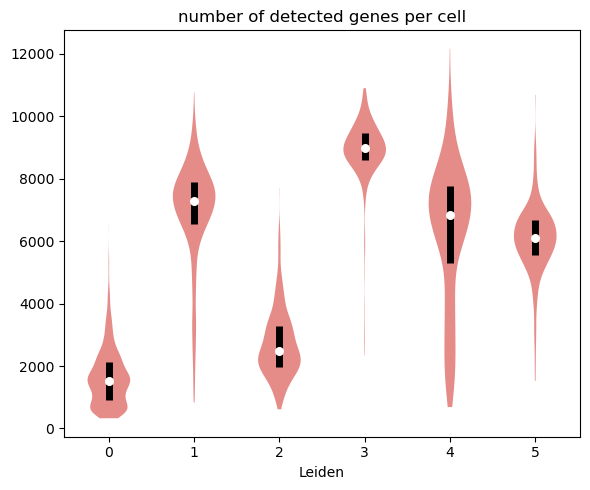

In [33]:
cls = list(adata.obs["leiden"].unique().sort_values())
dt = []

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

for i, cl in enumerate(cls):
    adata_sub = adata[adata.obs["leiden"] == cl]
    # d = np.asarray(adata_sub.layers['counts'].sum(axis=1)).ravel()
    d = np.asarray((adata_sub.layers['counts'] > 0).sum(axis=1)).ravel()
    dt.append(d)
    quartile1, medians, quartile3 = np.percentile(d, [25, 50, 75])
    ax.vlines(i+1, quartile1, quartile3, color='k', linestyle='-', lw=5)
    ax.scatter(i+1, medians, marker='o', color='white', s=30, zorder=3)

violin_parts = ax.violinplot(dt, showmeans=False, showmedians=False, showextrema=False)
for pc in violin_parts['bodies']:
    pc.set_facecolor("#D43F3A")
    pc.set_alpha(0.6)

# ax.set_ylim(0, 40)
ax.set_xticks(np.arange(1, len(cls)+1), cls)
ax.set_title("number of detected genes per cell")
ax.set_xlabel("Leiden")

plt.tight_layout()
plt.show()

# 3. Comparison against Nikolova et al 2025

In [4]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/Nikolova_2025/invitro_timecourse.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 52680 × 33538
    obs: '_index', 'culture', 'group', 'line', 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'percent.mt', 'sample', 'species'